# Experiment: CV HW1 Collaborative Scaffold

Objective:
- Complete homework Step 1-4 and the MLP part of Step 5 in a reusable way.
- Leave shared training and evaluation hooks so teammates can continue with CNN, ResNet, and ViT.


## Collaboration Notes

- Keep shared logic in `hw1_framework.py` so notebook cells stay short and easy to merge.
- Use the `RUN_*` flags before launching long experiments.
- Teammates should reuse the shared data split and training wrapper instead of writing separate loops.


In [1]:
# Core notebook imports.
from pathlib import Path
import copy

import pandas as pd

import hw1_framework as hw


In [2]:
# Resolve the project root and create shared output folders.
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "CV_HW1":
    PROJECT_DIR = Path("D:/PythonProjects/CV_HW1")

project_paths = hw.ensure_project_dirs(PROJECT_DIR)
runtime_config = hw.get_default_runtime_config(PROJECT_DIR)

# Fix the seed once so everyone uses the same dataset split and training randomness.
hw.set_seed(runtime_config["seed"])
device = hw.get_device()

print(f"Project directory: {PROJECT_DIR}")
print(f"Device: {device}")
print(f"Output folders: {project_paths}")


Project directory: D:\PythonProjects\CV_HW1
Device: cpu
Output folders: {'root': WindowsPath('D:/PythonProjects/CV_HW1'), 'data': WindowsPath('D:/PythonProjects/CV_HW1/data'), 'figures': WindowsPath('D:/PythonProjects/CV_HW1/figures'), 'models': WindowsPath('D:/PythonProjects/CV_HW1/models'), 'results': WindowsPath('D:/PythonProjects/CV_HW1/results')}


## Step 1-4: Data Loading, Split, And Visualization

This section covers the reusable part of the homework that all four models share.


In [3]:
# Load EMNIST Balanced with one fixed train/validation/test setup.
loaders = hw.load_emnist_balanced(
    data_dir=runtime_config["data_dir"],
    batch_size=runtime_config["batch_size"],
    valid_ratio=runtime_config["valid_ratio"],
    num_workers=runtime_config["num_workers"],
    subset_ratio=1.0,
    augment=runtime_config["augment"],
    rotation_deg=runtime_config["rotation_deg"],
    noise_std=runtime_config["noise_std"],
    blur=runtime_config["blur"],
    seed=runtime_config["seed"],
)

class_names = loaders["class_names"]
dataset_stats = hw.show_dataset_stats(
    loaders["train_dataset"],
    loaders["valid_dataset"],
    loaders["test_dataset"],
    class_names,
)
dataset_stats


  split  samples
  train   101520
  valid    11280
   test    18800
classes       47


,split,samples
0,train,101520
1,valid,11280
2,test,18800
3,classes,47


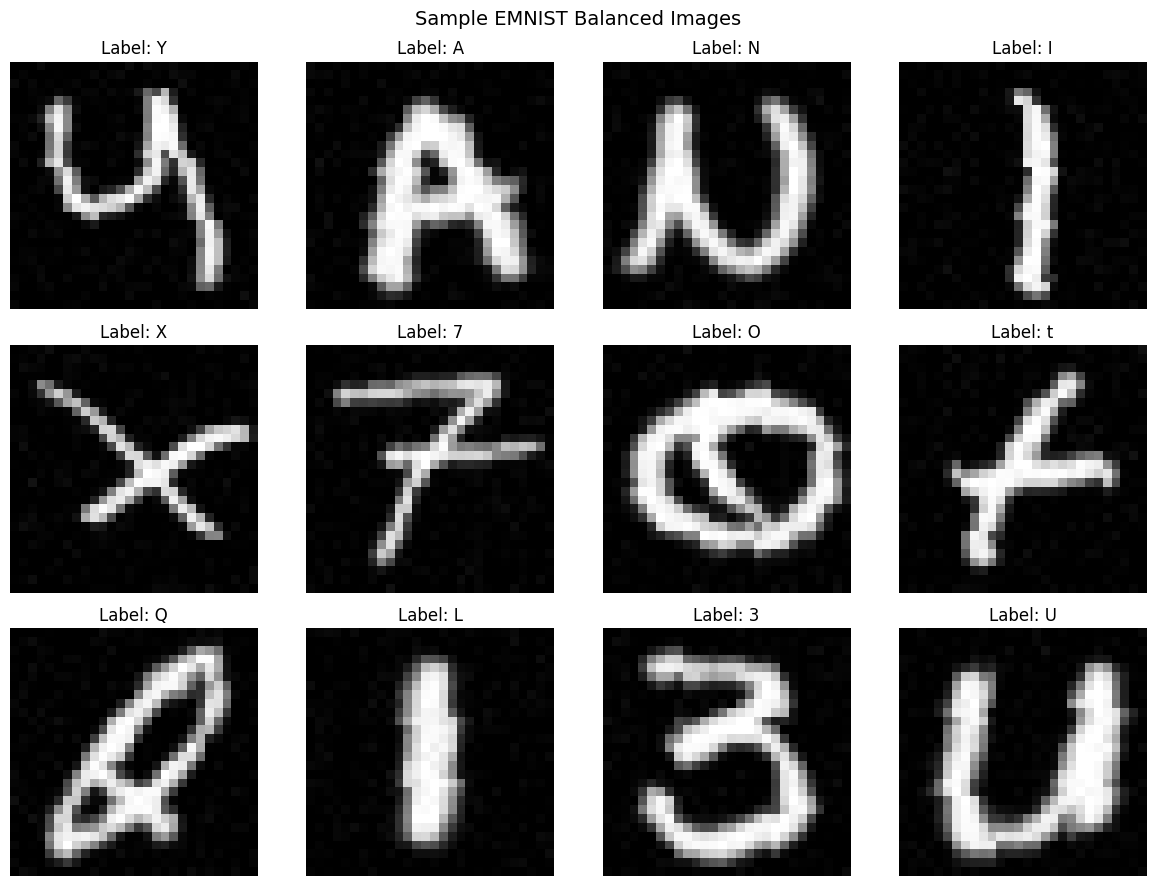

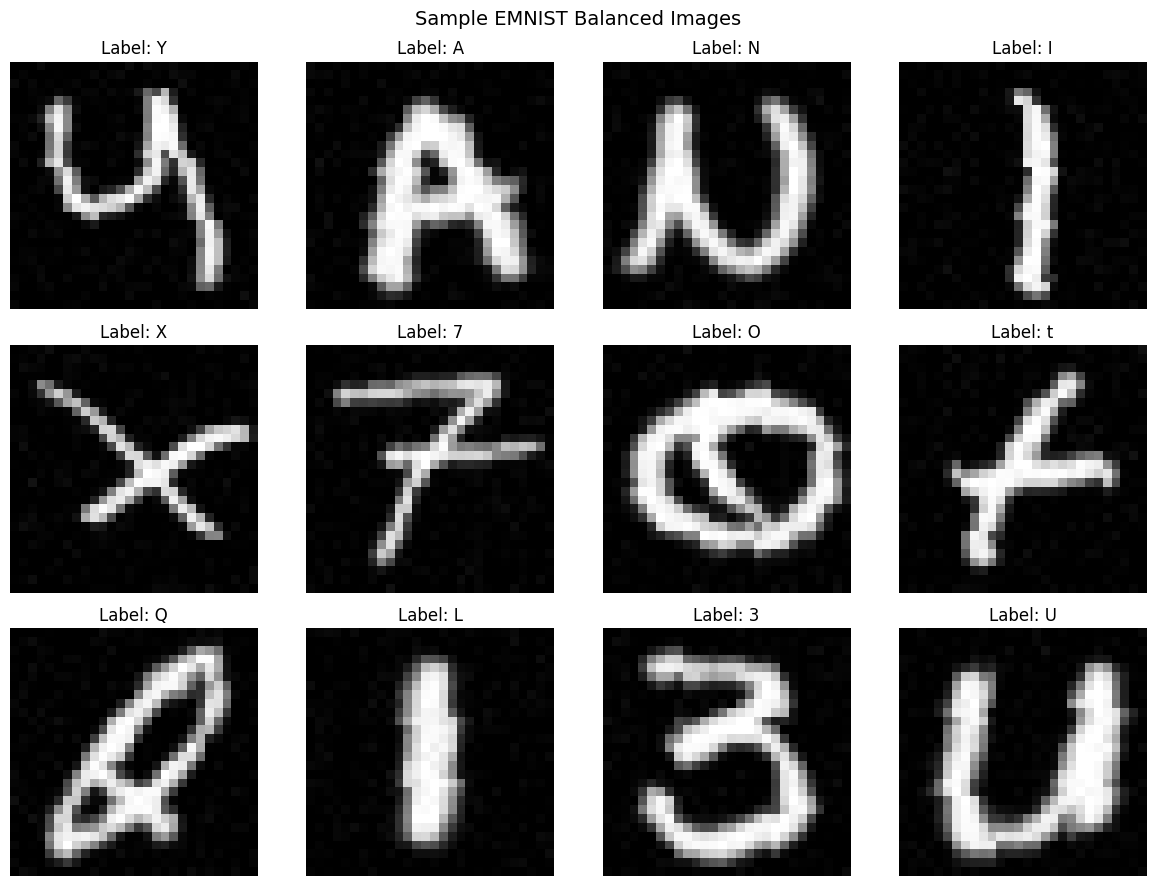

In [4]:
# Plot a few samples so the team can verify label coverage and image orientation early.
sample_figure = hw.show_sample_images(
    dataset=loaders["train_dataset"],
    class_names=class_names,
    num_samples=12,
    seed=runtime_config["seed"],
)
sample_figure


## MLP Baseline And Search Plan

The workflow below is the template that the other three model owners can reuse later.


In [5]:
# Start from one stable baseline, then replace one factor at a time.
mlp_config = hw.get_default_mlp_config()
mlp_search_plan = {
    "scheduler": ["StepLR", "CosineAnnealingLR", "ReduceLROnPlateau"],
    "activation": ["relu", "leaky_relu", "gelu"],
    "optimizer": ["adam", "sgd", "rmsprop"],
    "normalization": ["batchnorm", "layernorm", "none"],
    "dropout": [0.0, 0.3, 0.5],
}

# L1 and L2 change two fields together, so they are tracked separately from the single-factor loop.
mlp_regularization_trials = [
    {"name": "no_regularization", "l1_lambda": 0.0, "weight_decay": 0.0},
    {"name": "l1_regularization", "l1_lambda": 1e-6, "weight_decay": 0.0},
    {"name": "l2_regularization", "l1_lambda": 0.0, "weight_decay": 1e-4},
]

pd.Series(mlp_config, name="baseline_value")


input_dim                                             784
hidden_dims                               [512, 256, 128]
num_classes                                            47
activation                                           relu
normalization                                   batchnorm
dropout                                               0.3
optimizer                                            adam
learning_rate                                       0.001
scheduler                                          StepLR
scheduler_params           {'step_size': 5, 'gamma': 0.5}
weight_decay                                       0.0001
l1_lambda                                             0.0
epochs                                                 12
early_stopping_patience                                 4
Name: baseline_value, dtype: object

In [6]:
# Preview the MLP structure before training and record its parameter count for the report.
mlp_preview = hw.build_mlp(mlp_config)
print(mlp_preview)
print(f"Trainable parameters: {hw.count_parameters(mlp_preview):,}")


MLPClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.3, inplace=False)
    (13): Linear(in_features=128, out_features=47, bias=True)
  )
)
Trainable parameters: 573,999


In [7]:
# Keep heavy retraining opt-in. The saved baseline result is shown in the snapshot section below.
RUN_MLP_BASELINE = False

if RUN_MLP_BASELINE:
    mlp_baseline_result = hw.run_training_experiment(
        model_name="mlp_baseline",
        model_builder=hw.build_mlp,
        config=mlp_config,
        loaders=loaders,
        device=device,
        output_dir=project_paths["models"],
    )
    mlp_baseline_curves = hw.plot_training_curves(
        mlp_baseline_result["history"],
        "MLP Baseline",
    )
    mlp_baseline_summary = pd.DataFrame([mlp_baseline_result["summary"]])
    mlp_baseline_summary
else:
    print("??????? MLP baseline??????????????????")


??????? MLP baseline??????????????????


In [8]:
# Sequential search remains opt-in because it is time-consuming.
RUN_MLP_SEARCH = False

if RUN_MLP_SEARCH:
    search_tables = []
    tuned_mlp_config = copy.deepcopy(mlp_config)

    for factor_name, candidate_values in mlp_search_plan.items():
        factor_result = hw.run_single_factor_search(
            model_name="mlp",
            model_builder=hw.build_mlp,
            base_config=tuned_mlp_config,
            factor_name=factor_name,
            candidate_values=candidate_values,
            loaders=loaders,
            device=device,
            output_dir=project_paths["models"] / "search",
        )
        search_tables.append(factor_result["results"])
        tuned_mlp_config = factor_result["best_config"]

    regularization_rows = []
    best_regularized_config = copy.deepcopy(tuned_mlp_config)
    best_regularization_score = float("-inf")
    for trial in mlp_regularization_trials:
        trial_config = copy.deepcopy(tuned_mlp_config)
        trial_config["l1_lambda"] = trial["l1_lambda"]
        trial_config["weight_decay"] = trial["weight_decay"]
        trial_result = hw.run_training_experiment(
            model_name=f"mlp_{trial['name']}",
            model_builder=hw.build_mlp,
            config=trial_config,
            loaders=loaders,
            device=device,
            output_dir=project_paths["models"] / "search",
        )
        regularization_rows.append(
            {
                "factor": "regularization",
                "candidate": trial["name"],
                "best_valid_accuracy": trial_result["summary"]["best_valid_accuracy"],
                "best_epoch": trial_result["summary"]["best_epoch"],
                "training_time_sec": trial_result["summary"]["training_time_sec"],
            }
        )
        if trial_result["summary"]["best_valid_accuracy"] > best_regularization_score:
            best_regularization_score = trial_result["summary"]["best_valid_accuracy"]
            best_regularized_config = trial_config

    tuned_mlp_config = best_regularized_config
    mlp_search_results = pd.concat(
        [*search_tables, pd.DataFrame(regularization_rows)],
        ignore_index=True,
    )
    mlp_search_results
else:
    tuned_mlp_config = copy.deepcopy(mlp_config)
    print("??????? MLP ??????????????????????")


??????? MLP ??????????????????????


In [9]:
# Final training stays optional because the saved final checkpoint and metrics already exist.
RUN_MLP_FINAL = False

if RUN_MLP_FINAL:
    mlp_final_result = hw.run_training_experiment(
        model_name="mlp_best",
        model_builder=hw.build_mlp,
        config=tuned_mlp_config,
        loaders=loaders,
        device=device,
        output_dir=project_paths["models"],
    )
    mlp_final_curves = hw.plot_training_curves(
        mlp_final_result["history"],
        "MLP Best Model",
    )
    mlp_test_metrics = hw.evaluate_on_test(
        mlp_final_result["model"],
        loaders["test_loader"],
        device,
    )
    mlp_metric_table = pd.DataFrame([hw.summarize_metrics(mlp_test_metrics)])
    mlp_metric_table
else:
    print("????????? MLP???????????????????")


????????? MLP???????????????????


In [10]:
# Re-render the visualizations only when you really need to regenerate them.
if "mlp_final_result" in globals():
    prediction_figure = hw.preview_predictions(
        model=mlp_final_result["model"],
        loader=loaders["test_loader"],
        class_names=class_names,
        device=device,
        num_samples=6,
    )
    confusion_figure = hw.plot_confusion_matrix_from_preds(
        y_true=mlp_test_metrics["y_true"],
        y_pred=mlp_test_metrics["y_pred"],
        class_names=class_names,
        model_name="MLP",
    )
    prediction_figure
    confusion_figure
else:
    print("???????????????????????????")


???????????????????????????


In [11]:
# The saved small-sample comparison is shown below by default.
RUN_MLP_SMALL_SAMPLE = False

if RUN_MLP_SMALL_SAMPLE:
    mlp_small_sample_df, mlp_small_sample_runs = hw.run_small_sample_experiment(
        model_name="mlp",
        model_builder=hw.build_mlp,
        base_config=tuned_mlp_config,
        runtime_config=runtime_config,
        sample_ratios=[0.3, 0.5, 1.0],
        device=device,
        output_dir=project_paths["models"],
    )
    mlp_small_sample_df
else:
    print("????????????????????????????????")


????????????????????????????????


## ???????

???????? `results/`?`figures/` ? `models/` ?????????????? notebook ????????????????????????

### 1. ???????

,??
0,??????????????
1,???????? checkpoint
2,??? scheduler/activation/optimizer/normalizati...
3,?????????????????
4,??? 30% / 50% / 100% ??


### 2. ???????

,split,samples,classes
0,train,101520,47
1,valid,11280,47
2,test,18800,47


### 3. Baseline ?????????

...

,search_name,candidate,best_valid_accuracy,best_valid_loss,best_epoch,training_time_sec,selected
5,activation,gelu,0.8409,0.4761,8,143.4583,True
4,activation,leaky_relu,0.8360,0.4873,8,144.1985,False
3,activation,relu,0.8326,0.4912,8,144.3085,False
12,dropout,dropout_0.0,0.8605,0.4018,8,136.4010,True
13,dropout,dropout_0.3,0.8432,0.4720,8,141.1737,False
14,dropout,dropout_0.5,0.8057,0.5760,8,142.6361,False
9,normalization,batchnorm,0.8391,0.4731,8,140.4264,True
11,normalization,none,0.8281,0.5085,8,138.8103,False
10,normalization,layernorm,0.8275,0.5162,8,140.7383,False
7,optimizer,sgd_5e-2,0.8413,0.4679,8,141.0680,True


### 6. ???????

,sample_ratio,train_samples,best_valid_accuracy,test_accuracy,test_f1_macro
0,0.3,30456,0.8598,0.8601,0.8583
1,0.5,50760,0.8690,0.8709,0.8699
2,1.0,101520,0.8819,0.8795,0.8783


### 7. ??????

#### ??/????

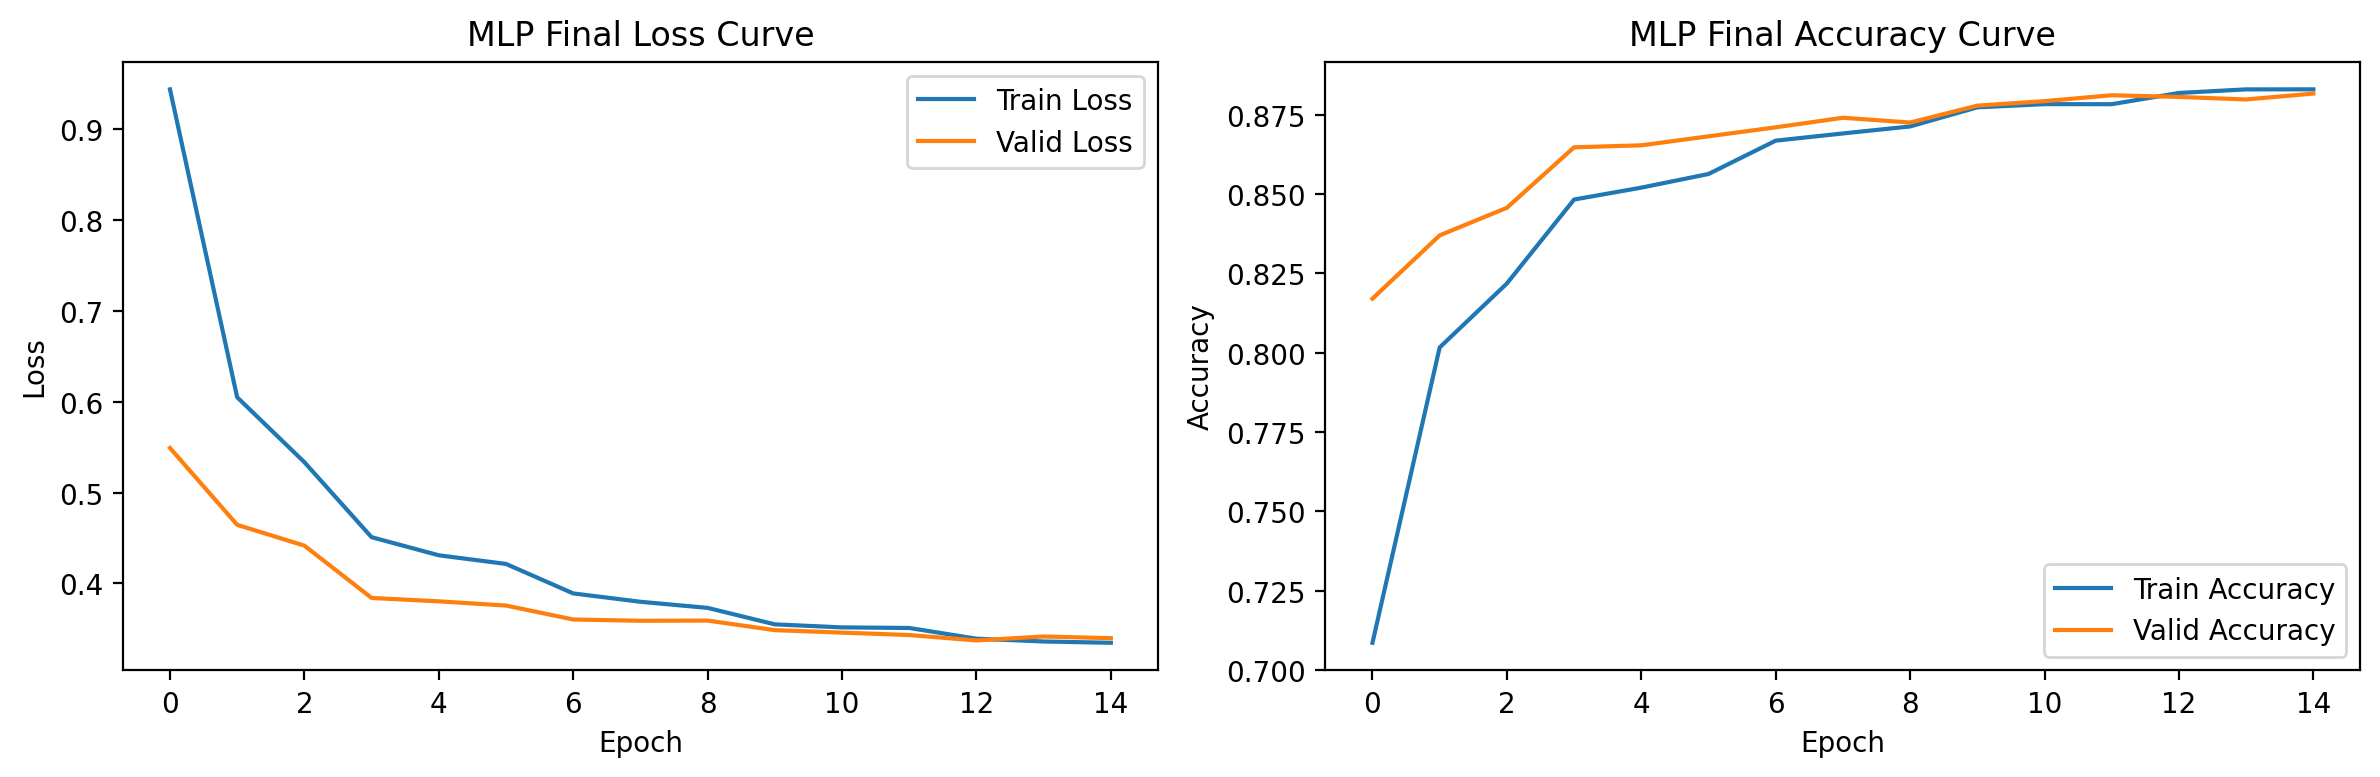

#### ? 6 ???????

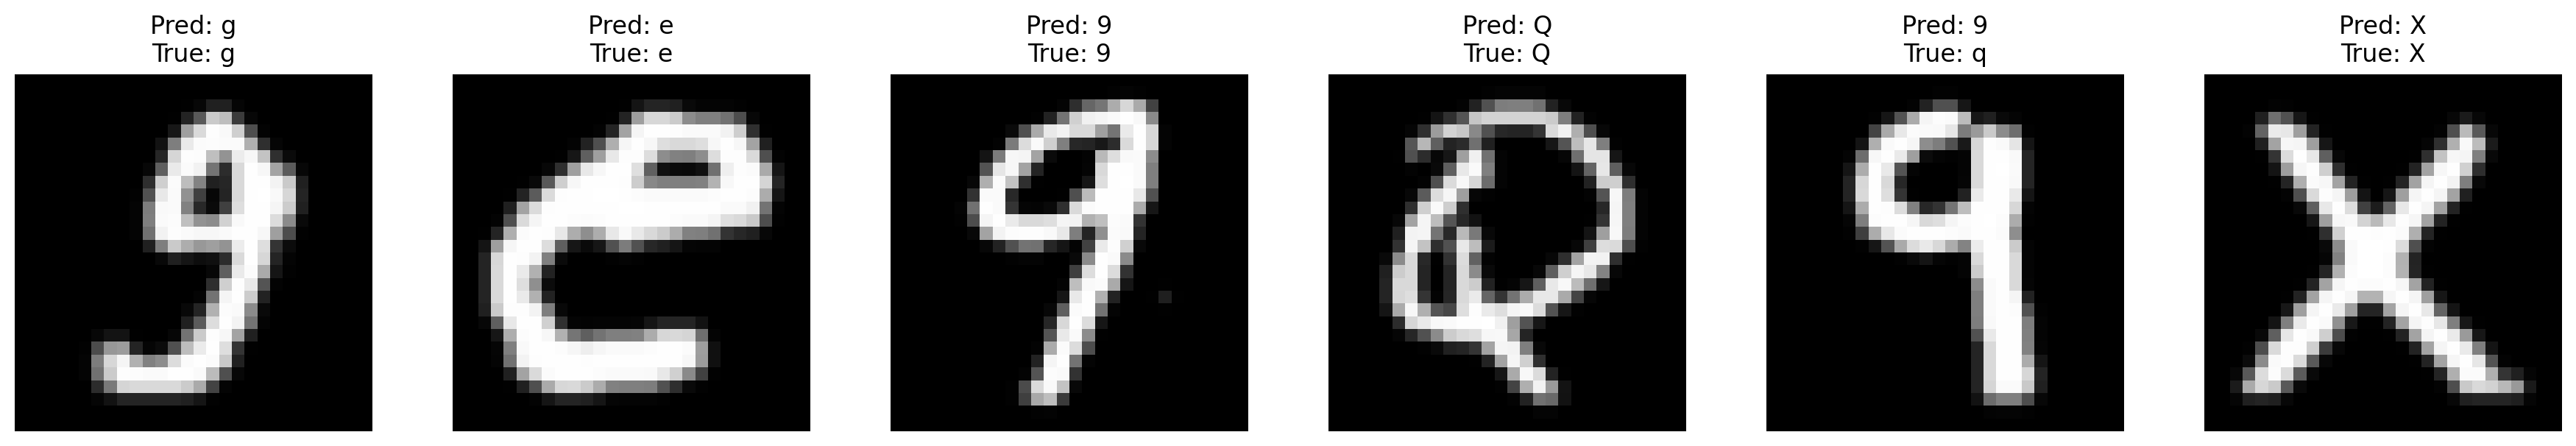

#### ???????

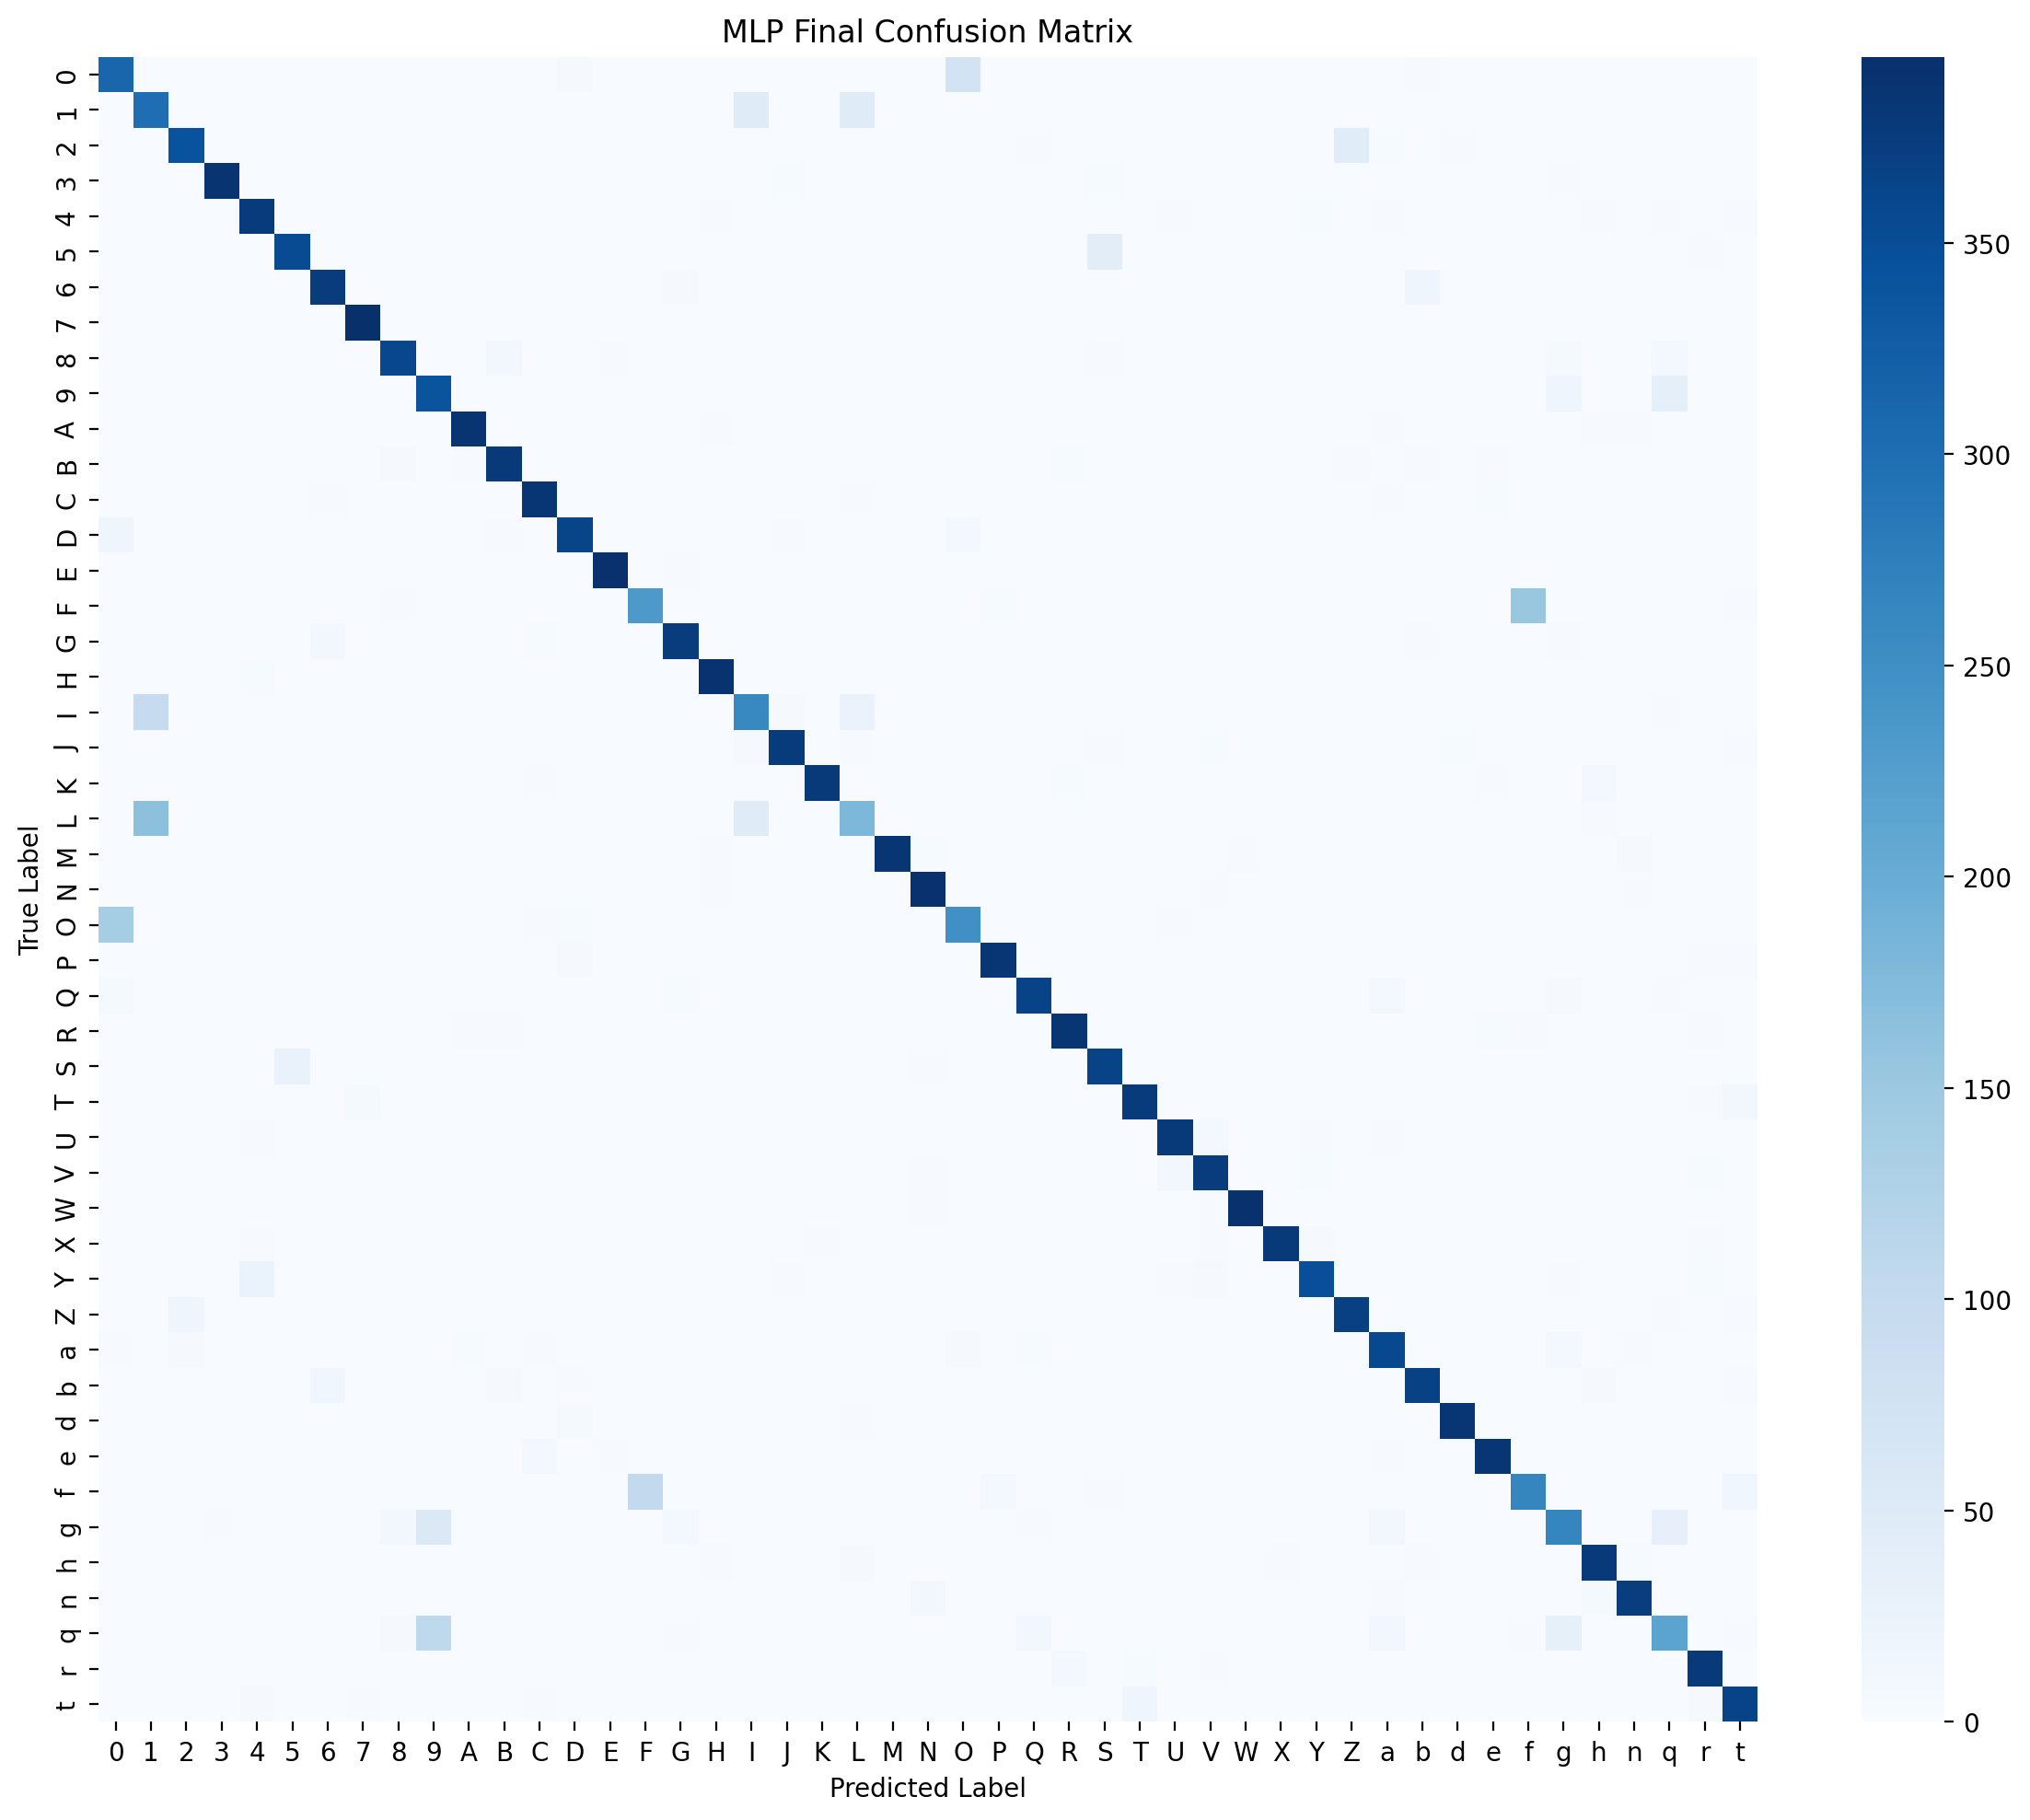

#### 30% / 50% / 100% ?????

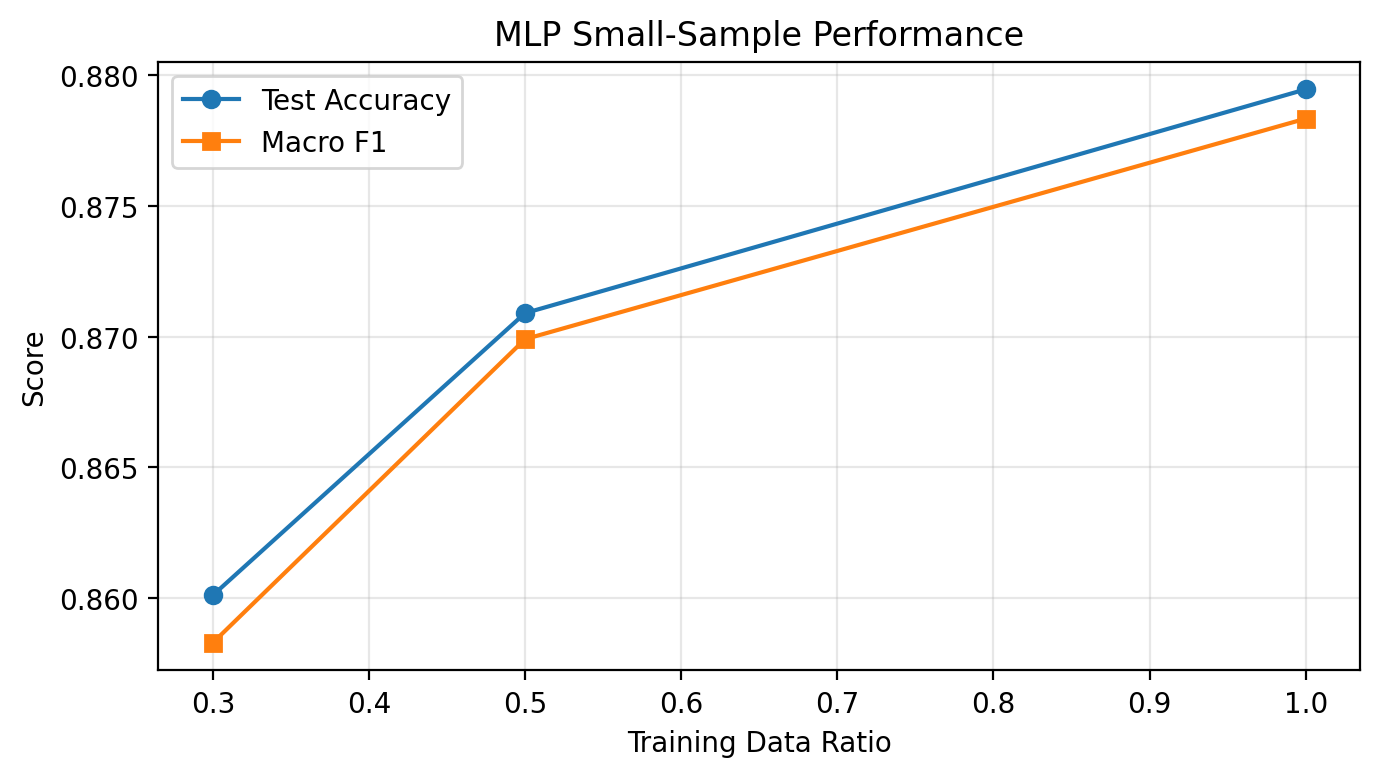

### 8. ????????

,??
0,True
1,True
2,True


In [12]:
# ?????????????????? notebook ???????????
import json
from IPython.display import Image, Markdown, display

saved_summary_path = PROJECT_DIR / "results" / "mlp_experiment_summary.json"
saved_small_sample_path = PROJECT_DIR / "results" / "mlp_small_sample_results.csv"
saved_search_path = PROJECT_DIR / "results" / "mlp_search_results.csv"
saved_metric_path = PROJECT_DIR / "results" / "mlp_metric_summary.csv"

figure_paths = {
    "??/????": PROJECT_DIR / "figures" / "mlp_final_curves.png",
    "? 6 ???????": PROJECT_DIR / "figures" / "mlp_final_predictions.png",
    "???????": PROJECT_DIR / "figures" / "mlp_final_confusion_matrix.png",
    "30% / 50% / 100% ?????": PROJECT_DIR / "figures" / "mlp_small_sample.png",
}

if saved_summary_path.exists():
    with saved_summary_path.open("r", encoding="utf-8") as f:
        saved_summary = json.load(f)

    display(Markdown("### 1. ???????"))
    completion_df = pd.DataFrame([
        {"??": "Step 1-4 ???????????", "??": "???", "??": "??????????????"},
        {"??": "MLP baseline", "??": "???", "??": "???????? checkpoint"},
        {"??": "MLP ????", "??": "???", "??": "??? scheduler/activation/optimizer/normalization/dropout/regularization ??"},
        {"??": "MLP ????", "??": "???", "??": "?????????????????"},
        {"??": "MLP ?????", "??": "???", "??": "??? 30% / 50% / 100% ??"},
    ])
    display(completion_df)

    display(Markdown("### 2. ???????"))
    dataset_snapshot = pd.DataFrame([
        {"split": "train", "samples": len(loaders["train_dataset"]), "classes": len(class_names)},
        {"split": "valid", "samples": len(loaders["valid_dataset"]), "classes": len(class_names)},
        {"split": "test", "samples": len(loaders["test_dataset"]), "classes": len(class_names)},
    ])
    display(dataset_snapshot)

    display(Markdown("### 3. Baseline ?????????"))
    metric_table = pd.DataFrame([
        {"stage": "baseline_valid", **saved_summary["baseline_valid_metrics"]},
        {"stage": "baseline_test", **saved_summary["baseline_test_metrics"]},
        {"stage": "final_valid", **saved_summary["final_valid_metrics"]},
        {"stage": "final_test", **saved_summary["final_test_metrics"]},
    ])
    display(metric_table.round(4))

    improvement_table = pd.DataFrame([
        {
            "??": "accuracy",
            "baseline_test": saved_summary["baseline_test_metrics"]["accuracy"],
            "final_test": saved_summary["final_test_metrics"]["accuracy"],
            "??": saved_summary["final_test_metrics"]["accuracy"] - saved_summary["baseline_test_metrics"]["accuracy"],
        },
        {
            "??": "f1_macro",
            "baseline_test": saved_summary["baseline_test_metrics"]["f1_macro"],
            "final_test": saved_summary["final_test_metrics"]["f1_macro"],
            "??": saved_summary["final_test_metrics"]["f1_macro"] - saved_summary["baseline_test_metrics"]["f1_macro"],
        },
    ])
    display(improvement_table.round(4))

    display(Markdown("### 4. ?? MLP ??"))
    final_config_df = pd.json_normalize(saved_summary["final_config"])
    display(final_config_df)

    display(Markdown("### 5. ??????"))
    search_df = pd.read_csv(saved_search_path)
    if "selected" not in search_df.columns:
        search_df["selected"] = False
        best_indices = search_df.groupby("search_name")["best_valid_accuracy"].idxmax()
        search_df.loc[best_indices, "selected"] = True
    display(search_df.sort_values(["search_name", "best_valid_accuracy"], ascending=[True, False]).round(4))

    display(Markdown("### 6. ???????"))
    small_sample_df = pd.read_csv(saved_small_sample_path)
    display(small_sample_df.round(4))

    display(Markdown("### 7. ??????"))
    for title, image_path in figure_paths.items():
        if image_path.exists():
            display(Markdown(f"#### {title}"))
            display(Image(filename=str(image_path)))

    display(Markdown("### 8. ????????"))
    artifact_rows = []
    for name, file_path in {
        "????": PROJECT_DIR / "results" / "mlp_best_config.json",
        "????": saved_metric_path,
        "????": saved_search_path,
        "?????": saved_small_sample_path,
        "????": saved_summary_path,
        "?? checkpoint": PROJECT_DIR / "models" / "mlp_final_best.pt",
    }.items():
        artifact_rows.append({"??": name, "??": str(file_path), "??": file_path.exists()})
    display(pd.DataFrame(artifact_rows))
else:
    print("??????????????? run_mlp_pipeline.py?")


## Scaffolds For The Other Three Models

These configs and builders are ready for the teammates who own CNN, ResNet, and ViT.


In [13]:
# Every teammate should start here and then tune only their own model-specific config.
cnn_config = hw.get_default_cnn_config()
resnet_config = hw.get_default_resnet_config()
vit_config = hw.get_default_vit_config()

scaffold_rows = []
for model_name, config in {
    "cnn": cnn_config,
    "resnet": resnet_config,
    "vit": vit_config,
}.items():
    model = hw.MODEL_BUILDERS[model_name](config)
    scaffold_rows.append(
        {
            "model": model_name,
            "trainable_parameters": hw.count_parameters(model),
            "config_ready": True,
        }
    )

pd.DataFrame(scaffold_rows)


D:\PythonProjects\CV_HW1\hw1_framework.py:595: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)


,model,trainable_parameters,config_ready
0,cnn,99183,True
1,resnet,312847,True
2,vit,544943,True


## Shared Step 6 Hook

Once all four best checkpoints are ready, use one shared evaluation cell to keep the comparison fair.


In [14]:
def evaluate_saved_models(best_model_paths, model_configs, shared_loaders, class_names, device):
    rows = []
    for model_name, checkpoint_path in best_model_paths.items():
        builder = hw.MODEL_BUILDERS[model_name]
        model = builder(model_configs[model_name]).to(device)
        hw.load_checkpoint(model, checkpoint_path, device)
        metrics = hw.evaluate_on_test(model, shared_loaders["test_loader"], device)
        rows.append({"model": model_name, **hw.summarize_metrics(metrics)})

        hw.preview_predictions(model, shared_loaders["test_loader"], class_names, device, num_samples=6)
        hw.plot_confusion_matrix_from_preds(
            metrics["y_true"],
            metrics["y_pred"],
            class_names,
            model_name.upper(),
        )

    return pd.DataFrame(rows)

# Example after all teammates finish their best models:
# best_model_paths = {
#     "mlp": project_paths["models"] / "mlp_best.pt",
#     "cnn": project_paths["models"] / "cnn_best.pt",
#     "resnet": project_paths["models"] / "resnet_best.pt",
#     "vit": project_paths["models"] / "vit_best.pt",
# }
# model_configs = {
#     "mlp": tuned_mlp_config,
#     "cnn": cnn_config,
#     "resnet": resnet_config,
#     "vit": vit_config,
# }
# final_report_df = evaluate_saved_models(best_model_paths, model_configs, loaders, class_names, device)


## Handoff Reminder

Read `README.md` before dividing work further. It records the file map, shared API, recommended ownership split, and the merge checklist.
